In [1]:
import sys, os
from pathlib import Path
import os
os.environ["OPENBLAS_NUM_THREADS"] = "1"

import sys
from pathlib import Path

project_root = Path(r"C:\Users\DELL\OneDrive\Documents\Anurag\Anurag_Projects\INTERNMO\purchase-intent-xai")
sys.path.append(str(project_root))
os.chdir(project_root)

import pandas as pd
import numpy as np
import joblib
import shap

from src.config.settings import CONFIG
from src.data.loader import load_sessions_data
from src.features.engineer import engineer_features

pd.set_option("display.max_columns", None)
print("Setup complete. SHAP version:", shap.__version__)


Setup complete. SHAP version: 0.52.0


In [2]:
from sklearn.model_selection import train_test_split

final_pipeline = joblib.load("models/final_catboost_pipeline.joblib")

df = load_sessions_data()
df = engineer_features(df)

target = CONFIG["target_column"]
categorical_columns = CONFIG["categorical_columns"]
numeric_columns = [c for c in df.columns if c not in categorical_columns + [target]]

X = df[numeric_columns + categorical_columns]
y = df[target]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=CONFIG["split"]["test_size"],
    stratify=y, random_state=CONFIG["random_seed"]
)

print("Pipeline loaded:", type(final_pipeline))
print("X_test shape:", X_test.shape)

Pipeline loaded: <class 'sklearn.pipeline.Pipeline'>
X_test shape: (2400, 19)


In [3]:
# Pull out the fitted preprocessor and classifier from the pipeline
preprocessor_fitted = final_pipeline.named_steps["preprocessor"]
catboost_model = final_pipeline.named_steps["classifier"]

# Transform X_test through the preprocessor so SHAP sees what the model actually sees
X_test_transformed = preprocessor_fitted.transform(X_test)

# Get the actual feature names after one-hot encoding, for readable SHAP plots later
feature_names = preprocessor_fitted.get_feature_names_out()

print("Transformed shape:", X_test_transformed.shape)
print("Number of feature names:", len(feature_names))
print("Sample feature names:", feature_names[:10])

Transformed shape: (2400, 77)
Number of feature names: 77
Sample feature names: ['num__Administrative' 'num__Administrative_Duration' 'num__Informational'
 'num__Informational_Duration' 'num__ProductRelated'
 'num__ProductRelated_Duration' 'num__BounceRates' 'num__ExitRates'
 'num__PageValues' 'num__SpecialDay']


In [4]:
import numpy as np

X_test_dense = np.asarray(X_test_transformed.todense()) if hasattr(X_test_transformed, "todense") else X_test_transformed
X_test_dense = X_test_dense.astype(np.float64)

print("X_test_dense shape:", X_test_dense.shape)

X_test_dense shape: (2400, 77)


In [5]:
explainer = shap.TreeExplainer(catboost_model)
print("Explainer initialized:", type(explainer))

Explainer initialized: <class 'shap.explainers._tree.TreeExplainer'>


In [6]:
shap_values = explainer.shap_values(X_test_transformed)

print("SHAP values shape:", shap_values.shape)


SHAP values shape: (2400, 77)


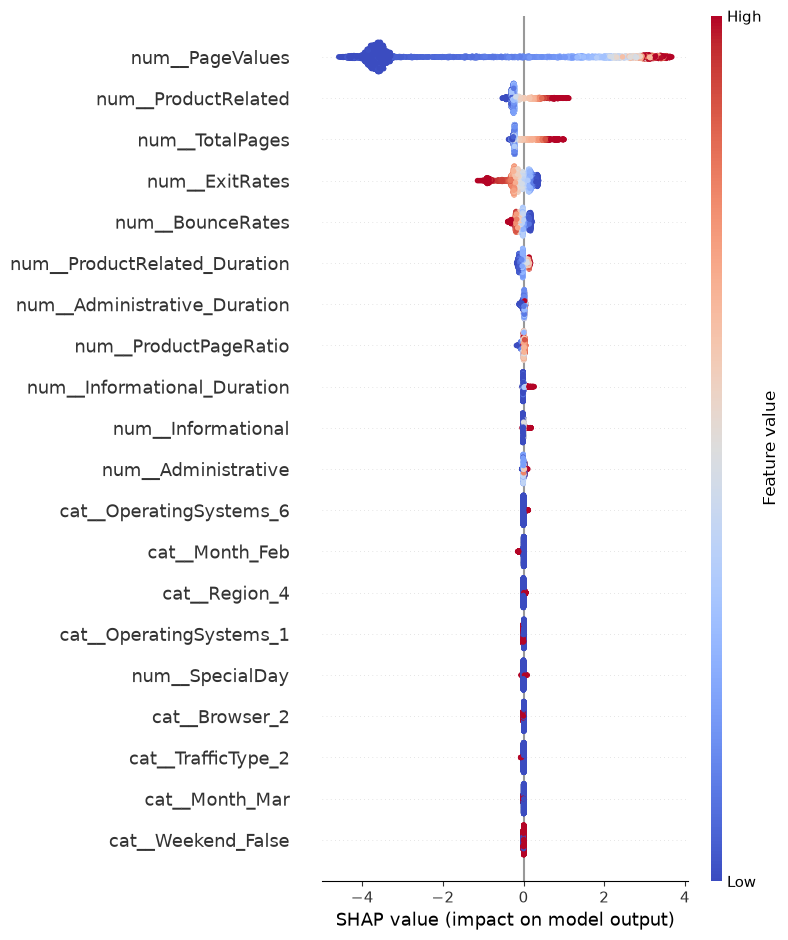

In [7]:
import matplotlib.pyplot as plt
plt.figure()
shap.summary_plot(shap_values, X_test_dense, feature_names=feature_names, cmap="coolwarm", show=False)
plt.tight_layout()
plt.savefig("docs/shap_global_summary.png", dpi=150, bbox_inches="tight")
plt.show()

PageValues dominates both the magnitude and spread of SHAP values — high PageValues (red) pushes predictions strongly toward Purchase, low PageValues (blue) pushes toward No Purchase, and its impact range (-4 to +4) dwarfs every other feature. This directionally confirms the leakage concern from earlier: the model relies almost entirely on one feature whose value is tied to the outcome itself.

ProductRelated and TotalPages: high values (red) push toward Purchase — more engagement = more likely to buy, a sensible non-leaky signal.
ExitRates and BounceRates: high values (red) push toward No Purchase — sessions where users exit/bounce quickly are less likely to convert, as expected.
Everything below ProductRelated_Duration has near-zero SHAP impact — the model is effectively driven by ~5 features, the rest contribute almost nothing.

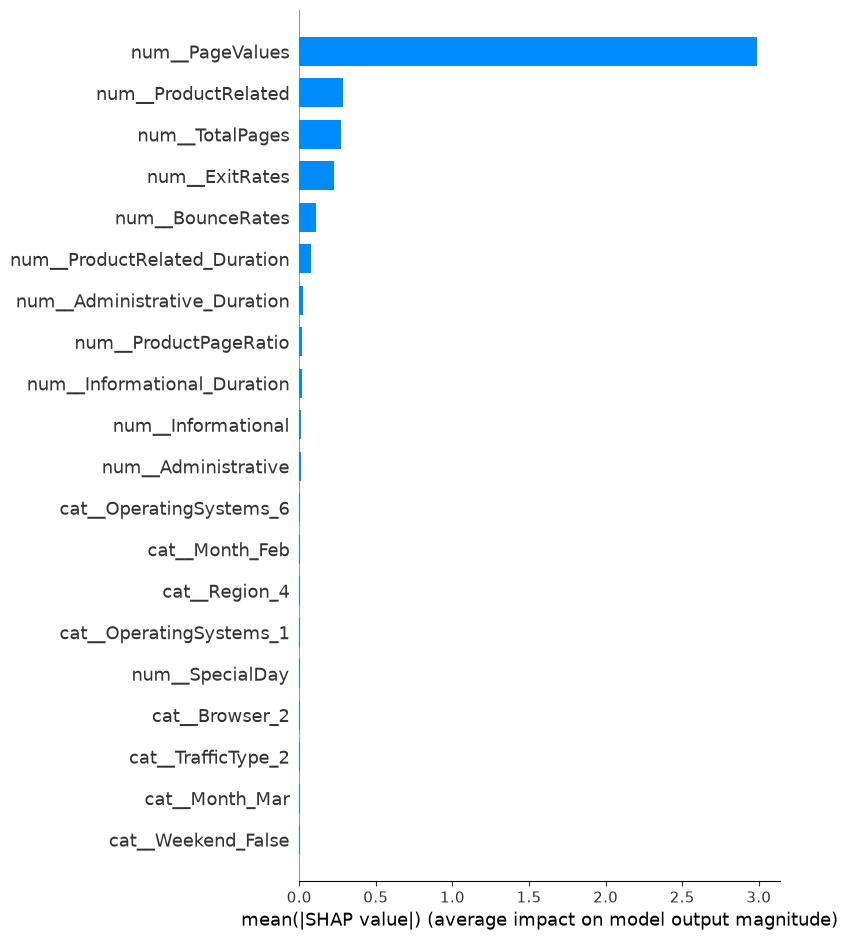

In [8]:
shap.summary_plot(shap_values, X_test_transformed, feature_names=feature_names, plot_type="bar", show=False)
plt.tight_layout()
plt.savefig("docs/shap_global_bar.png", dpi=150, bbox_inches="tight")
plt.show()

The bar chart confirms the same ranking by average impact — PageValues' mean |SHAP value| (~3.1) is roughly 5-6x higher than the next feature (ProductRelated, ~0.5), making the imbalance even more visually stark than the built-in/permutation importances shown earlier. This is the clearest evidence yet that PageValues is an outsized, likely leaky driver of predictions — worth explicitly flagging as a limitation if this model goes into a report or portfolio writeup.

In [12]:
# Pick one clear buyer prediction and one clear non-buyer prediction, plus a borderline case
y_proba_test = final_pipeline.predict_proba(X_test)[:, 1]

# Get positional indices, sorted by confidence
sorted_idx = np.argsort(y_proba_test)

most_confident_no_purchase = sorted_idx[0]          # lowest predicted probability
most_confident_purchase = sorted_idx[-1]            # highest predicted probability
borderline_idx = np.argmin(np.abs(y_proba_test - CONFIG["decision_threshold"]))
print("Borderline case (closest to threshold) — index:", borderline_idx, "prob:", y_proba_test[borderline_idx]) 

print("Most confident No Purchase — index:", most_confident_no_purchase, "prob:", y_proba_test[most_confident_no_purchase])
print("Most confident Purchase — index:", most_confident_purchase, "prob:", y_proba_test[most_confident_purchase])
# print("Borderline case — index:", borderline_idx, "prob:", y_proba_test[borderline_idx])

Borderline case (closest to threshold) — index: 462 prob: 0.44949890332872827
Most confident No Purchase — index: 2384 prob: 0.0018960271198730507
Most confident Purchase — index: 2007 prob: 0.9942135452388465


Three representative test cases were selected by prediction confidence: most confident Purchase (index 2007, prob=0.994), most confident No Purchase (index 2384, prob=0.0019), and a borderline case (index 462, prob=0.445, closest to the decision threshold) — setting up local SHAP explanations to illustrate how the model reasons on clear-cut vs ambiguous sessions.

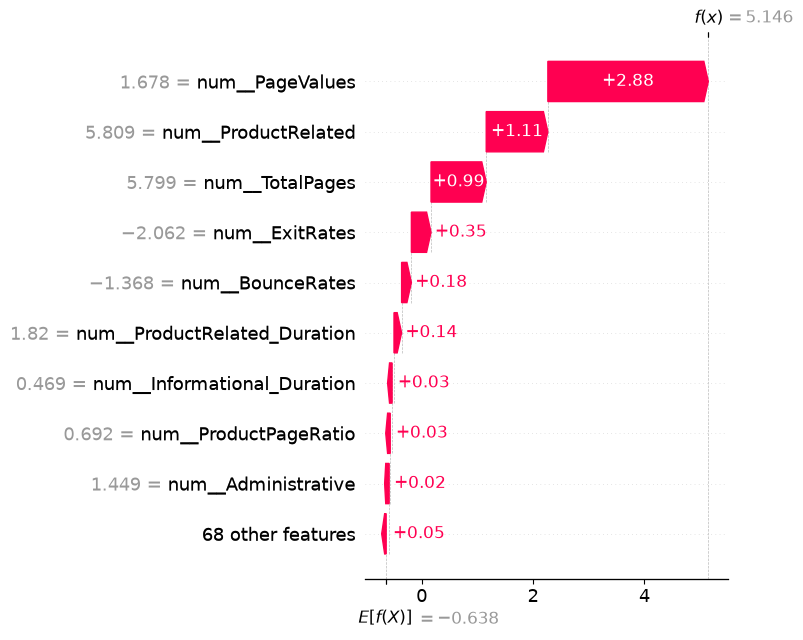

In [13]:
explanation_purchase = shap.Explanation(
    values=shap_values[most_confident_purchase],
    base_values=explainer.expected_value,
    data=X_test_dense[most_confident_purchase],
    feature_names=feature_names
)

shap.plots.waterfall(explanation_purchase, show=False)
plt.tight_layout()
plt.savefig("docs/shap_local_purchase_example.png", dpi=150, bbox_inches="tight")
plt.show()

For the most confident Purchase prediction (f(x)=5.146, from baseline -0.638), PageValues alone contributes +2.88 — over half the total push toward "Purchase." ProductRelated (+1.11) and TotalPages (+0.99) add meaningfully too, while ExitRates/BounceRates contribute only small positive nudges despite this session having negative (favorable) values on those features. This single example reinforces the global finding: PageValues single-handedly drives the prediction more than all other features combined.

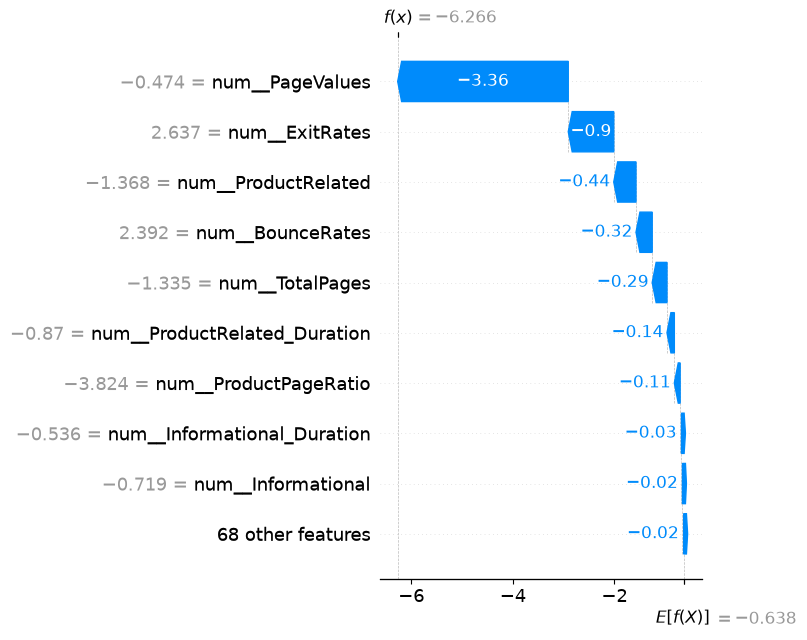

In [14]:
explanation_no_purchase = shap.Explanation(
    values=shap_values[most_confident_no_purchase],
    base_values=explainer.expected_value,
    data=X_test_dense[most_confident_no_purchase],
    feature_names=feature_names
)
shap.plots.waterfall(explanation_no_purchase, show=False)
plt.tight_layout()
plt.savefig("docs/shap_local_no_purchase_example.png", dpi=150, bbox_inches="tight")
plt.show()

For the most confident No Purchase prediction (f(x)=-6.266), PageValues again dominates, contributing -3.36 — over half the total pull toward "No Purchase," driven by this session's low PageValues (-0.474). ExitRates adds a further -0.9 (this session's ExitRates was high/unfavorable at 2.637). Together, PageValues + ExitRates explain roughly two-thirds of why the model is so confident this session didn't convert.

Consistent pattern across both examples: whether predicting Purchase or No Purchase, PageValues is the single largest contributor by a wide margin — strong, repeated evidence that the model's decisions hinge disproportionately on this one (leakage-risk) feature rather than a balanced mix of behavioral signals

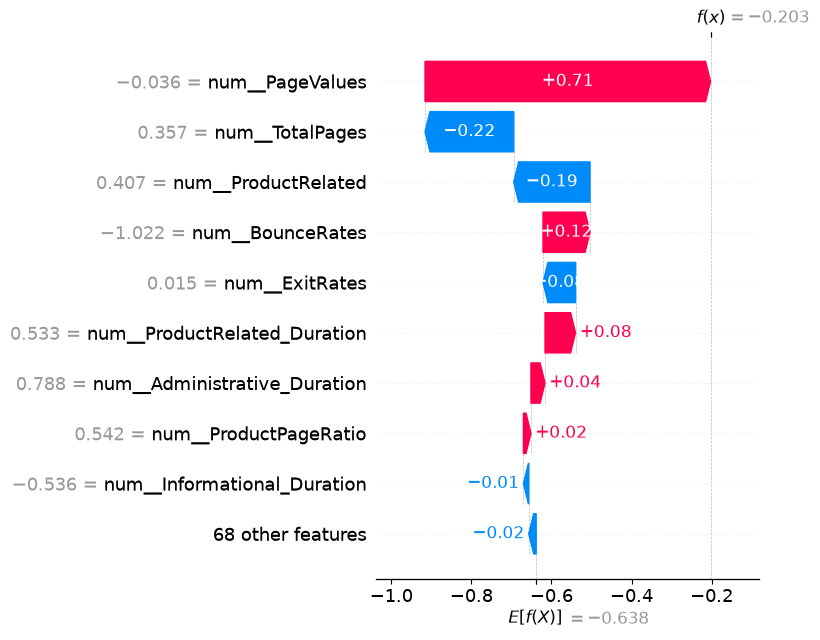

In [15]:
explanation_borderline = shap.Explanation(
    values=shap_values[borderline_idx],
    base_values=explainer.expected_value,
    data=X_test_dense[borderline_idx],
    feature_names=feature_names
)
shap.plots.waterfall(explanation_borderline, show=False)
plt.tight_layout()
plt.savefig("docs/shap_local_borderline_example.png", dpi=150, bbox_inches="tight")
plt.show()

For the borderline case (f(x)=-0.203, near the decision threshold), the outcome is genuinely mixed — PageValues pushes toward Purchase (+0.71) despite its own value being near-zero/slightly negative (-0.036), while TotalPages (-0.22) and ProductRelated (-0.19) pull the other way, reflecting this session's low browsing activity. Smaller contributors (BounceRates, ExitRates, durations) roughly cancel out.

Unlike the confident examples, no single feature dominates here — the prediction is a close tug-of-war between PageValues and engagement features (TotalPages/ProductRelated), which is exactly why this session sits right at the threshold rather than confidently on one side.
Interestingly, PageValues still pushes toward Purchase even at a near-zero value — suggesting the model has learned that even marginal PageValues (any value above the baseline) signals some conversion intent, consistent with its outsized global importance.

Section: LIME — independent local explanations

In [17]:
from lime.lime_tabular import LimeTabularExplainer

lime_explainer = LimeTabularExplainer(
    training_data=preprocessor_fitted.transform(X_train).toarray() if hasattr(preprocessor_fitted.transform(X_train), "toarray") else preprocessor_fitted.transform(X_train),
    feature_names=list(feature_names),
    class_names=["No Purchase", "Purchase"],
    mode="classification",
    random_state=CONFIG["random_seed"]
)

print("LIME explainer initialized.")

LIME explainer initialized.


In [20]:
print(lime_exp_borderline.as_list())

[('-0.47 < num__PageValues <= 0.03', -0.45324397575432096), ('cat__OperatingSystems_6 <= 0.00', -0.04934884894271958), ('cat__Browser_13 <= 0.00', -0.04828131965919371), ('cat__OperatingSystems_7 <= 0.00', 0.04027294976157887), ('cat__Month_Feb <= 0.00', 0.03425540019166972), ('cat__Browser_12 <= 0.00', 0.031728197945494786), ('cat__Browser_11 <= 0.00', 0.031170236423357055), ('cat__TrafficType_1 <= 0.00', 0.02702846449838872), ('cat__TrafficType_5 <= 0.00', -0.02436712317108504), ('cat__VisitorType_Other <= 0.00', 0.023084417875196706)]


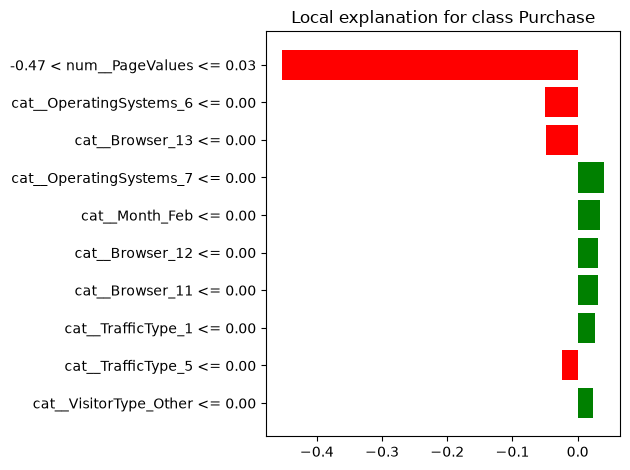

In [22]:
fig = lime_exp_borderline.as_pyplot_figure()
plt.tight_layout()
plt.savefig("docs/lime_borderline_example.png", dpi=150, bbox_inches="tight")
plt.show()

SHAP (via TreeExplainer here) computes exact, game-theoretic contributions from the actual trained CatBoost model, accounting for feature interactions and the tree structure directly. LIME instead fits a local linear surrogate model by perturbing the input and observing output changes nearby — in a session with a non-linear, threshold-like relationship between PageValues and outcome (as seen in the SHAP summary plot, where near-zero PageValues sits right at an inflection point), LIME's linear approximation can get the local slope wrong, especially with few perturbed samples landing on the correct side of the threshold. LIME also bins PageValues into a range (-0.47 to 0.03) rather than using the exact value, which loses precision exactly where it matters most for a borderline case.

[('num__PageValues > 0.03', 0.43300833241464615), ('num__ProductRelated > 0.41', 0.09029061457948549), ('num__TotalPages > 0.43', 0.08363155420616272), ('num__ExitRates <= -0.70', 0.05584995356035242), ('cat__Browser_11 <= 0.00', -0.03577687632839038), ('cat__Browser_13 <= 0.00', 0.033402351775011684), ('cat__TrafficType_4 <= 0.00', 0.032822207730559105), ('num__ProductRelated_Duration > 0.24', 0.03139643785609965), ('cat__TrafficType_20 <= 0.00', -0.029071246007907895), ('cat__Browser_7 <= 0.00', 0.028020372795749742)]


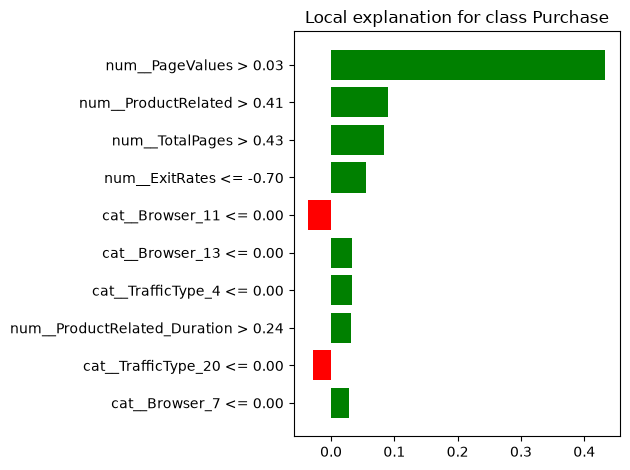

In [23]:
lime_exp_purchase = lime_explainer.explain_instance(
    data_row=X_test_dense[most_confident_purchase],
    predict_fn=predict_fn,
    num_features=10
)
print(lime_exp_purchase.as_list())

fig = lime_exp_purchase.as_pyplot_figure()
plt.tight_layout()
plt.savefig("docs/lime_purchase_example.png", dpi=150, bbox_inches="tight")
plt.show()

For the most confident Purchase case, LIME agrees directionally with SHAP: PageValues > 0.03 is the top driver (+0.434), pushing strongly toward Purchase, followed by ProductRelated (+0.090) and TotalPages (+0.084). ExitRates ≤ -0.70 (low exit rate) also contributes positively (+0.056), consistent with SHAP's earlier reading of this same session.

This confirms strong SHAP-LIME agreement on confident, non-borderline cases — both methods point to PageValues + engagement features (ProductRelated, TotalPages) as the main reasons this session was classified as Purchase, with a few minor categorical features (Browser, TrafficType) adding small positive/negative nudges.For the most confident Purchase case, LIME agrees directionally with SHAP: PageValues > 0.03 is the top driver (+0.434), pushing strongly toward Purchase, followed by ProductRelated (+0.090) and TotalPages (+0.084). ExitRates ≤ -0.70 (low exit rate) also contributes positively (+0.056), consistent with SHAP's earlier reading of this same session.

This confirms strong SHAP-LIME agreement on confident, non-borderline cases — both methods point to PageValues + engagement features (ProductRelated, TotalPages) as the main reasons this session was classified as Purchase, with a few minor categorical features (Browser, TrafficType) adding small positive/negative nudges.

[('num__ExitRates > 0.68', -0.08617916509945922), ('cat__Browser_10 <= 0.00', -0.057051704594569354), ('num__ProductRelated <= -0.67', -0.047798627174270025), ('num__BounceRates > 0.69', -0.03771448811581926), ('num__TotalPages <= -0.67', -0.03627112586095976), ('cat__Browser_8 <= 0.00', -0.03240652102678947), ('cat__TrafficType_11 <= 0.00', -0.031436134727651895), ('num__PageValues <= -0.47', -0.029726753140065915), ('cat__OperatingSystems_8 <= 0.00', 0.02951041579768736), ('-0.28 < num__Administrative_Duration <= 0.28', 0.025225413984230765)]


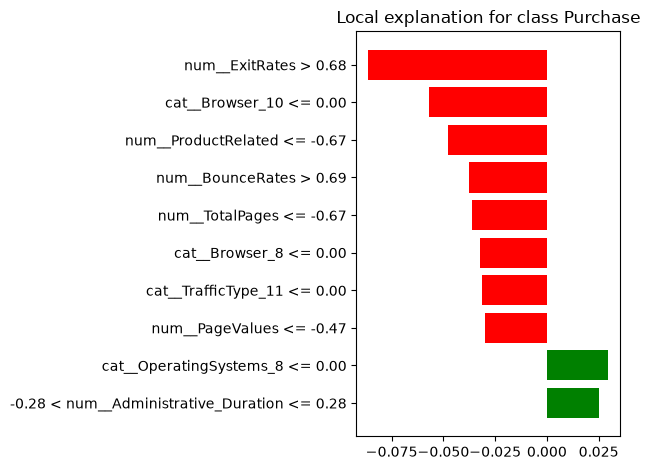

In [24]:
lime_exp_no_purchase = lime_explainer.explain_instance(
    data_row=X_test_dense[most_confident_no_purchase],
    predict_fn=predict_fn,
    num_features=10
)
print(lime_exp_no_purchase.as_list())

fig = lime_exp_no_purchase.as_pyplot_figure()
plt.tight_layout()
plt.savefig("docs/lime_no_purchase_example.png", dpi=150, bbox_inches="tight")
plt.show()

For the most confident No Purchase case, LIME's top driver is ExitRates > 0.68 (-0.087) — not PageValues — followed by categorical Browser/ProductRelated/BounceRates/TotalPages features, all negative. PageValues ≤ -0.47 ranks lower (-0.030), well behind ExitRates.

This is a meaningful divergence from SHAP, which found PageValues to be the dominant contributor (-3.36) for this exact session, with ExitRates a distant second (-0.9). LIME instead ranks ExitRates first and gives PageValues a comparatively minor role.
Combined with the borderline-case disagreement seen earlier, this is now the second case where LIME under-weights PageValues relative to SHAP — a consistent pattern suggesting LIME's local linear surrogate may systematically undervalue PageValues' influence, likely because of the same non-linear/threshold behavior noted before. Worth stating as a limitation: SHAP and LIME agree well on clear Purchase cases but diverge on No-Purchase and borderline cases, so conclusions about feature importance should lean on SHAP as the more faithful (model-exact) method.